In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [59]:
df = pd.read_csv("banknotes.csv")
df

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [60]:
print(df.isnull().sum())

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [61]:

print(df.isnull().sum())

Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64


In [62]:
# # Simple visual pattern checks
# num_cols = df.select_dtypes(include=[np.number]).columns
# print("Numeric columns:", list(num_cols))
# # 1) Histograms for numeric features
# df[num_cols].hist(figsize=(10,8))
# plt.suptitle('Histograms of numeric features')
# plt.show()
# # 2) Correlation heatmap
# plt.figure(figsize=(8,6))
# sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
# plt.title('Correlation matrix')
# plt.show()
# # 3) Pairplot (sample up to 200 rows to keep it quick)
# sample = df[num_cols].sample(n=min(200, len(df))) if len(df) > 200 else df[num_cols]
# sns.pairplot(sample)
# plt.suptitle('Pairplot (sample)', y=1.02)
# plt.show()
# # 4) Simple scatter of first two numeric columns
# if len(num_cols) >= 2:
#     x, y = num_cols[0], num_cols[1]
#     plt.figure(figsize=(6,5))
#     if 'class' in df.columns or 'Class' in df.columns:
#         hue_col = 'class' if 'class' in df.columns else 'Class'
#         sns.scatterplot(data=df, x=x, y=y, hue=hue_col, palette='Set1')
#     else:
#         sns.scatterplot(data=df, x=x, y=y)
#     plt.title(f'Scatter: {x} vs {y}')
#     plt.show()

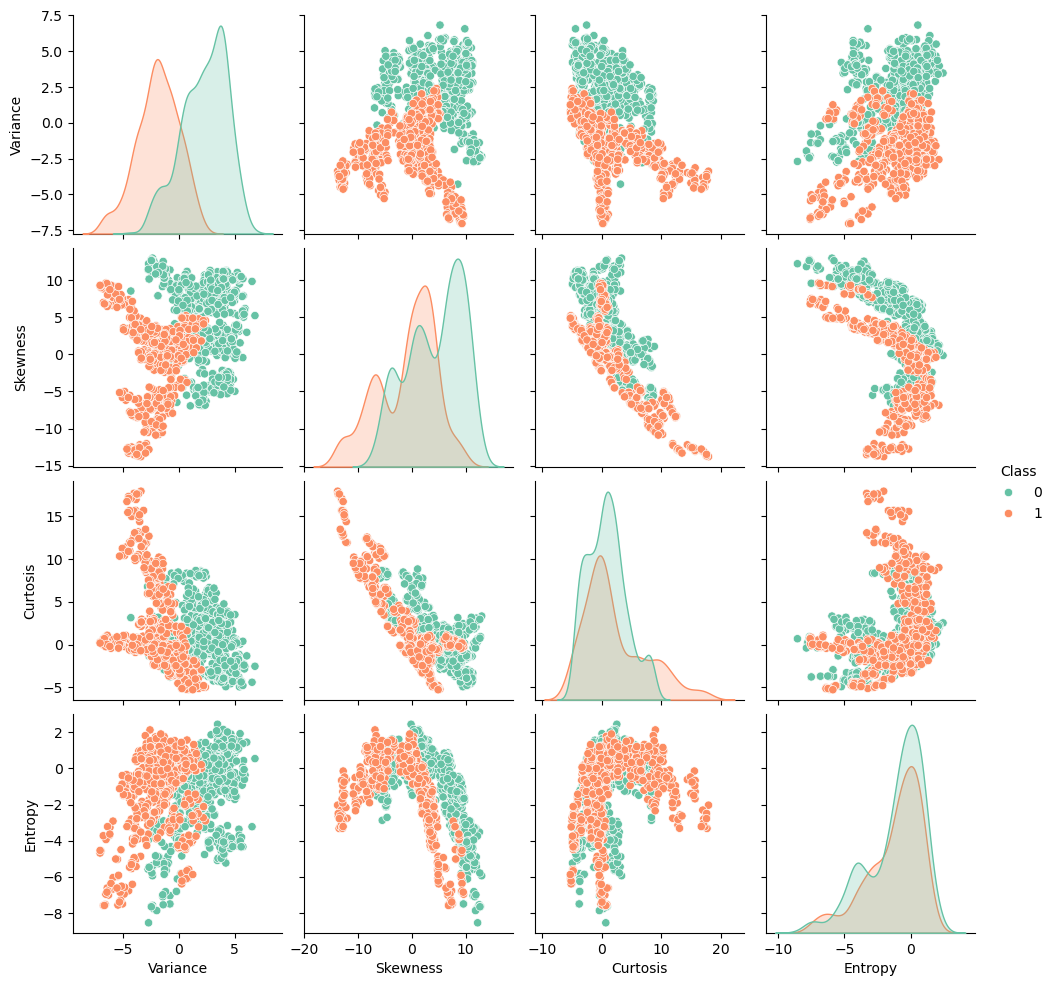

In [63]:
# Pairplot with safe hue selection
if 'class' in df.columns or 'Class' in df.columns:
    hue_col = 'class' if 'class' in df.columns else 'Class'
    sns.pairplot(df, hue=hue_col, palette='Set2')
else:
    sns.pairplot(df)
plt.show()

In [64]:
# # check the distribution of the target variable
# if 'class' in df.columns or 'Class' in df.columns:
#     target_col = 'class' if 'class' in df.columns else 'Class'
#     plt.figure(figsize=(6,4))
#     sns.countplot(data=df, x=target_col, palette='Set3')
#     plt.title(f'Distribution of target variable: {target_col}')
#     plt.show()

In [65]:
x = df.drop('Class', axis=1)
y = df['Class']


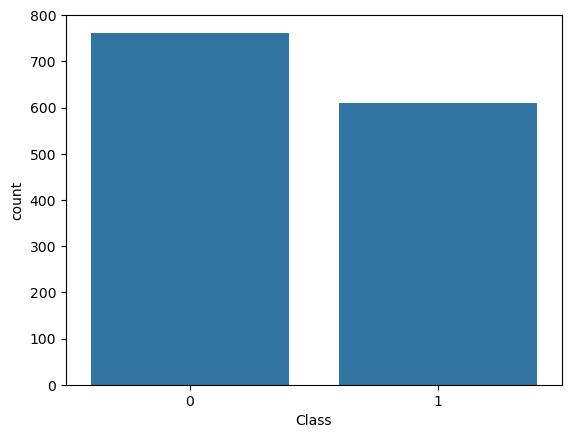

In [66]:
sns.countplot(x = y);

In [67]:
df['Class'].value_counts()

Class
0    762
1    610
Name: count, dtype: int64

In [68]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

In [69]:
# # Simple 75/25 stratified train/test split
# from sklearn.model_selection import train_test_split
# # detect target column (adjust if needed)
# target = 'Class' if 'Class' in df.columns else ('class' if 'class' in df.columns else df.columns[-1])
# X = df.drop(columns=[target])
# y = df[target]
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
# print('X_train, X_test shapes:', X_train.shape, X_test.shape)
# print('y_train distribution:\n', y_train.value_counts(normalize=True))
# print('y_test distribution:\n', y_test.value_counts(normalize=True))

In [70]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=0)

In [71]:
x_train.shape, y_train.shape

((1029, 4), (1029,))

In [72]:
# from sklearn.model_selection import train_test_split
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# # choose target column from banknotes.csv
# target = 'Class' if 'Class' in df.columns else ('class' if 'class' in df.columns else df.columns[-1])
# X = df.drop(columns=[target])
# y = df[target]
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.25, stratify=y, random_state=42)
# clf = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
# print('Train accuracy:', accuracy_score(y_train, clf.predict(X_train)))
# print('Test accuracy:', accuracy_score(y_test, y_pred))
# print('\nClassification report:')
# print(classification_report(y_test, y_pred))
# print('Confusion matrix:')
# print(confusion_matrix(y_test, y_pred))
# print('\nFeature importances:')
# for name, score in zip(X.columns, clf.feature_importances_):
#     print(f'{name}: {score:.4f}')

In [73]:
from sklearn.tree import DecisionTreeClassifier 
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [74]:
y_pred = dt.predict(x_test)

First 10 predictions:
[1 0 1 0 0 0 0 0 1 1]

First 10 actual values:
[1 0 1 0 0 0 0 0 1 1]

Prediction counts:
0    197
1    146
Name: count, dtype: int64

Sample inputs:
      Variance   Skewness  Curtosis  Entropy
1023   -1.7713 -10.766500  10.21840 -1.00430
642     5.1321  -0.031048   0.32616  1.11510
1196   -2.0149   3.687400  -1.93850 -3.89180
31      1.4884   3.627400   3.30800  0.48921
253     5.2868   3.257000  -1.37210  1.16680

Sample predictions:
[1 0 1 0 0]


In [75]:
from sklearn.metrics import accuracy_score


In [76]:
accuracy_score(y_test, y_pred)

0.9883381924198251

In [77]:
x.columns

Index(['Variance', 'Skewness', 'Curtosis', 'Entropy'], dtype='object')

In [78]:
dt.feature_importances_

array([0.60347212, 0.2197106 , 0.15040355, 0.02641374])

KeyError: 'class'

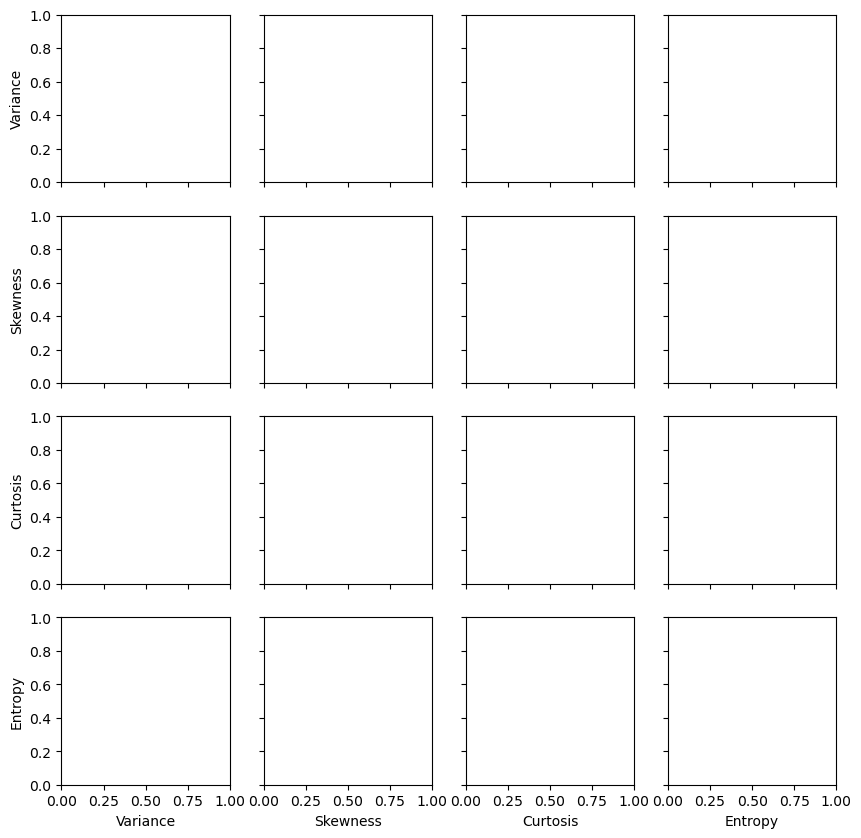

In [79]:
sns.pairplot(df[x.columns], hue='class', palette='Set1')

C:\Users\shrey\AppData\Local\Temp\ipykernel_1168\803659393.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')


C:\Users\shrey\AppData\Local\Temp\ipykernel_1168\803659393.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')


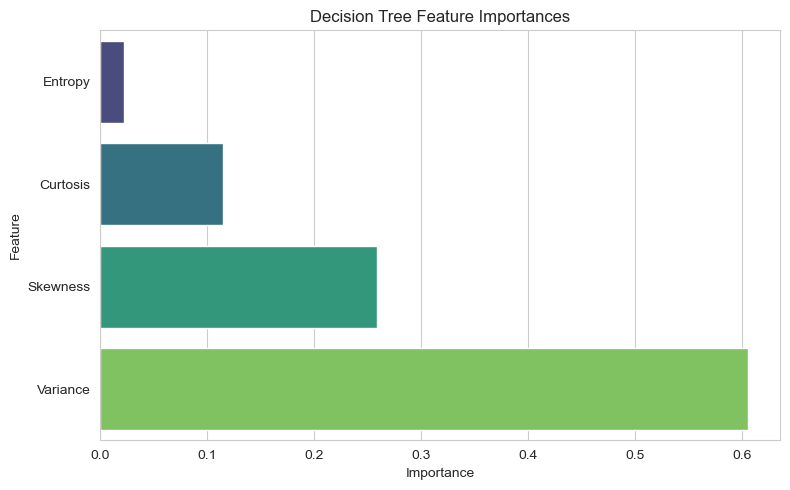

In [81]:
# # Plot feature importances from the trained decision tree using seaborn
# import pandas as pd
# # import matplotlib.pyplot as plt
# feature_importances = pd.Series(clf.feature_importances_, index=X.columns)
# feature_importances = feature_importances.sort_values(ascending=True).reset_index()
# feature_importances.columns = ['feature', 'importance']
# sns.set_style('whitegrid')
# plt.figure(figsize=(8,5))
# sns.barplot(x='importance', y='feature', data=feature_importances, palette='viridis')
# plt.title('Decision Tree Feature Importances')
# plt.xlabel('Importance')
# plt.ylabel('Feature')
# plt.tight_layout()
# plt.show()

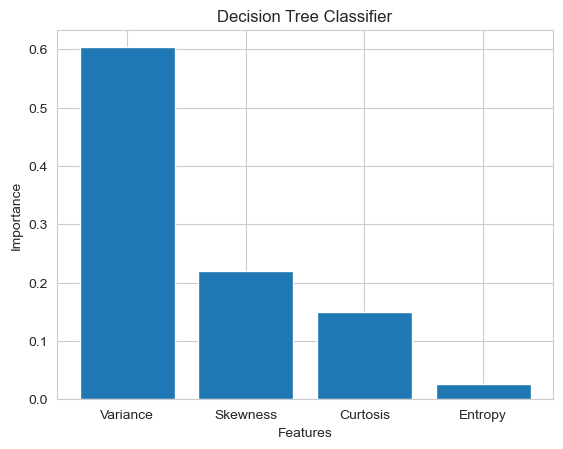

In [82]:
plt.title('Decision Tree Classifier')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.bar(x.columns, dt.feature_importances_);

In [83]:
#plot the tree

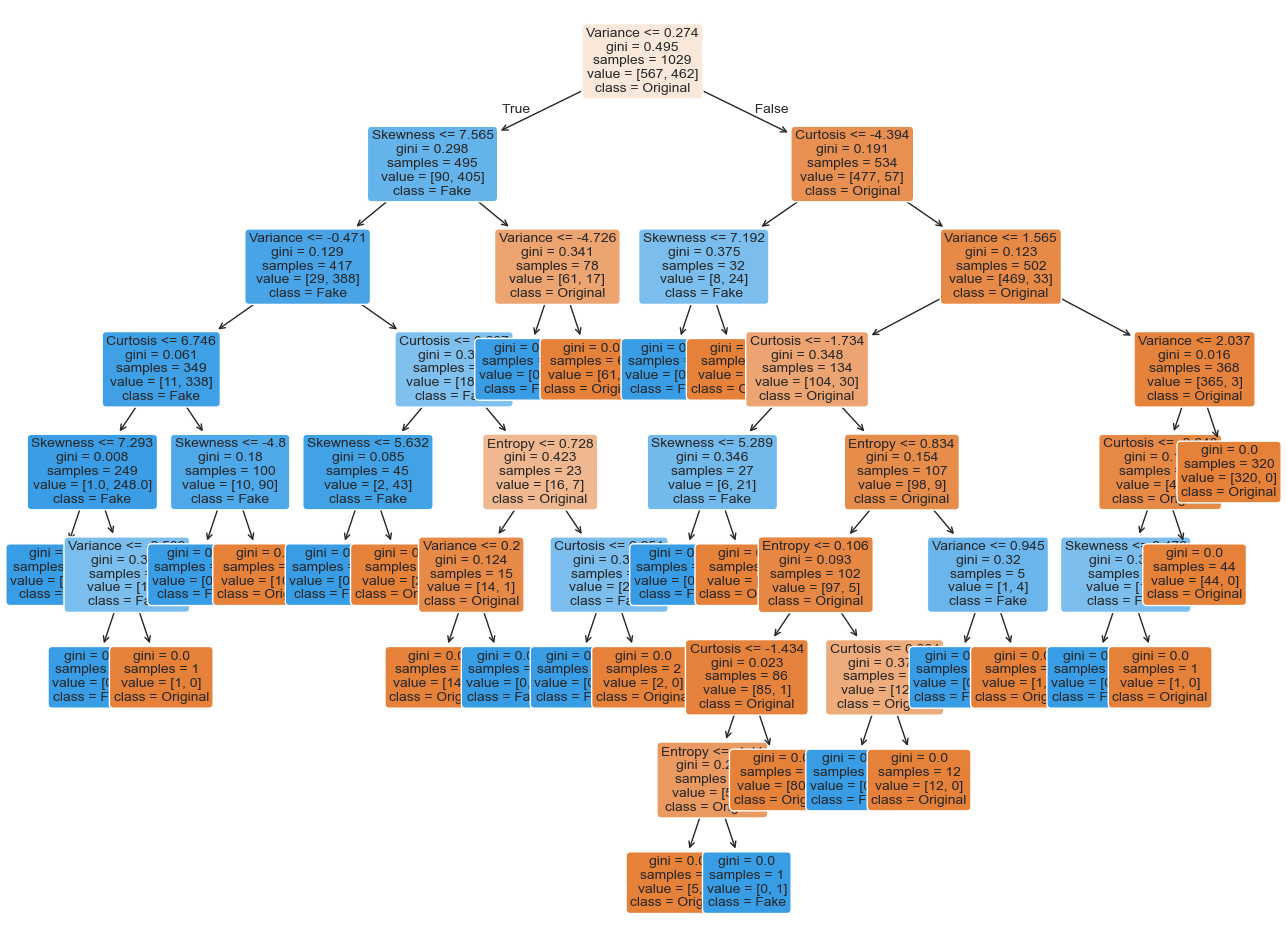

In [88]:
from sklearn.tree import plot_tree
plt.figure(figsize=(16,12))
plot_tree(dt, rounded=True,
    filled=True, 
    feature_names=x.columns, 
    class_names=['Original', 'Fake'], 
    fontsize=10);

In [ ]:
# Show predicted values and compare with actual test labels
import pandas as pd
print('First 10 predictions:')
print(y_pred[:10])
print('\nFirst 10 actual values:')
print(y_test.values[:10])
print('\nPrediction counts:')
print(pd.Series(y_pred).value_counts())
print('\nSample inputs:')
print(x_test.head())
print('\nSample predictions:')
print(dt.predict(x_test.head()))

In [ ]:
# Predict for a new banknote sample (Original or Fake)
import pandas as pd
new_data = pd.DataFrame([
    {
        'Variance': 4.86600,
        'Skewness': -1.63830,
        'Curtosis': 0.92420,
        'Entropy': 0.64500
    }
])
print('Input values:')
print(new_data)
new_pred = dt.predict(new_data)
label_map = {0: 'Original', 1: 'Fake'}
print('Predicted class code:', new_pred[0])
print('Predicted label:', label_map.get(new_pred[0], new_pred[0]))

Input values:
   Variance  Skewness  Curtosis  Entropy
0     4.866   -1.6383    0.9242    0.645
Predicted class: 0
